# Correlated Noises

Now we allow for *correlated noises* which acts simultaneously on the whole multi-qubit system

In [404]:
import Pkg

println(Base.active_project())
Pkg.status()

G:\UNIPA\COLLAB\SAGNIK\killing_decoherence\julia\Project.toml
Status `G:\UNIPA\COLLAB\SAGNIK\killing_decoherence\julia\Project.toml`
  [7073ff75] IJulia v1.34.4
  [682c06a0] JSON v1.6.0
  [98e50ef6] JuliaFormatter v2.3.0
  [b964fa9f] LaTeXStrings v1.4.0
  [23fbe1c1] Latexify v0.16.10
  [e6f89c97] LoggingExtras v1.2.0
  [91a5bcdd] Plots v1.41.6
  [49802e3a] ProgressBars v1.5.1
  [33c8b6b6] ProgressLogging v0.1.6
  [92933f4c] ProgressMeter v1.11.0
  [6e0679c1] QuantumOptics v1.2.6
  [295af30f] Revise v3.14.3
  [2913bbd2] StatsBase v0.34.10
  [5d786b92] TerminalLoggers v0.1.7
  [ade2ca70] Dates v1.11.0
  [37e2e46d] LinearAlgebra v1.12.0
  [56ddb016] Logging v1.11.0
  [9a3f8284] Random v1.11.0
  [fa267f1f] TOML v1.0.3


In [405]:
using LinearAlgebra
using Plots
using Revise
using JSON
using Latexify

using Random
using StatsBase

using ProgressMeter
ProgressMeter.ijulia_behavior(:append)
using Printf

# ==============================================
# Custom logger
using Logging, TerminalLoggers, ProgressLogging
# Display debug messages
global_logger(TerminalLogger(stderr, Logging.Info))
debuglogger = ConsoleLogger(stderr, Logging.Debug)

includet("../julia/src/logging.jl")
# ==============================================

includet("../julia/src/UnitaryDilation/UnitaryDilation.jl")
includet("../julia/src/PetzMaps.jl")
# includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
includet("../julia/src/configurations.jl")
includet("../julia/src/custom_plots.jl")
includet("../julia/src/quantum_states.jl")

using .UnitaryDilation
# using .DecoKiller
using .PetzMaps

In [406]:
function apply_noise(model, ρ, n_qubits)
  ρf = apply_channel(model.kraus_fwd, ρ, n_qubits)
  # Enforce physicality (hermitianicity and trace 1)
  # enforce_physical!(ρf)
  return ρf
end


function recovery(model, ρ)
  ρr, η = apply_collision(model, ρ)
  # enforce_physical!(ρr)
  return ρr, η
end

recovery (generic function with 1 method)

## Setup

In [407]:
n_qubits = 2
beta = 1.0
gamma = 0.1
dt = 1.0
n_steps = 2

recovery_type = "auto"  # 'auto', 'random', 'codespace', 'inputspace'

fidelities = Float64[]
fidelities_ref = Float64[]  # Store the fidelities of the noisy state evolving without recovery

# Random but reproducible states
seed = 42
rng = Xoshiro(seed)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

### Initial States
We create the recovery state `sigma` and a random initial state

In [408]:
# Choose a reference state for the recovery
# sigma = thermal_state(n_qubits, beta)
sigma = codespace_dm(n_qubits, 0.6, 0.4)
ρ0 = copy(sigma)  # Default to the thermal state, but will be overwritten based on recovery_type

if recovery_type == "random"
    ψ = random_state(n_qubits)
    ρ0 = ψ * ψ'
elseif recovery_type == "auto"
    ρ0 = copy(sigma)
elseif recovery_type == "codespace"
    p = rand()
    max_x = p * (1-p)  # Maximum allowed magnitude for |x|^2
    radius = sqrt(rand() * max_x)
    x = radius * exp(2π * im * rand())
    ρ = codespace_dm(n_qubits, p, x)
    ρ0 = ρ + sigma
    ρ0 = ρ0 / tr(ρ0)  # Normalize to ensure it's a valid density matrix
elseif recovery_type == "inputstate"
    a, b = rand(rng, 2)
    ψ = input_state(n_qubits, a, b)
    ρ0 = ψ * ψ'
end

display(latexify(sigma; fmt="%.3f")) # display as LaTeX table
display(latexify(ρ0; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Noise

Now if we have 1-qubit noises like:
- $\Omega_1$ : amplitude damping,
- $\Omega_2$ : phase damping,

we must create the whole noise object given by correlated Kraus operators:
$$
\Omega_1[\rho] \equiv \sum_i K_i \rho K_i^\dagger,
$$
and
$$
\Omega_1[\rho_A\otimes\rho_B] \equiv \sum_i (K_i\otimes\mathbb{I}) \rho_A\otimes\rho_B (K_i^\dagger\otimes\mathbb{I}) +
\sum_i (\mathbb{I}\otimes K_i) \rho_A\otimes\rho_B (\mathbb{I}\otimes K_i^\dagger),
$$
now we have:
$$
\Omega_1[\rho_A\otimes\rho_B] \equiv \sum_i (K_i\otimes K_i) \rho_A\otimes\rho_B (K_i^\dagger \otimes K_i^\dagger),
$$

In [409]:
n_systems = 1
noise_probabilities = [
  (0.5, "phase_damping"),
  (0.5, "amplitude_damping"),
]

# ======================================
# Precompute the supermaps once
correlated_noises = true
noise_options = [
  NoiseObj(noise_model[2], noise_model[1], sigma, gamma, dt; correlated=correlated_noises)
  for noise_model in noise_probabilities
]

# ======================================
# Fix the real Noise model
noise = "amplitude_damping"
println("Chosen noise:\t\t$noise")
real_noise_idx = findfirst(n -> n.name == noise, noise_options)
real_noise = noise_options[real_noise_idx]
# Take the relevant Kraus operators
real_kraus = real_noise.kraus
real_model = CollisionModel(real_kraus, sigma, n=n_systems)

Chosen noise:		amplitude_damping


CollisionModel{ComplexF64}(4, 2, ComplexF64[0.6 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.4 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.4 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.4 + 0.0im], Matrix{ComplexF64}[[1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.951229424500714 + 0.0im], [0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.3084843301758462 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im]], Matrix{ComplexF64}[[0.9377357865020971 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.04009500836215027 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.03251284251216906 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.9788224951049025 + 0.0im], [0.1747967534246785 + 0.0im 0.0 + 0

In [410]:
real_noise_idx = findfirst(n -> n.name == "Caca", noise_options)
real_noise_idx === nothing

true

In [411]:
kraus_to_superop(noise_options[1].kraus)

16×16 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.951229+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.

In [412]:
model = CollisionModel(noise_options[1].kraus, sigma, n=n_systems)
model.kraus_fwd
_, M_noise = build_superoperators(model)
M_noise

16×16 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …       0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im          0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.951229+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.

### Initialization

In [413]:

config = RecoveryConfig(
    "notebook", # name of the experiment
    "../experiments/example",
    sigma,      # reference state
    "auto",     # recovery type
    real_noise,
    n_qubits,
    n_steps,
    1,          # number of states
    seed,
    rng,
    dt,
    0.8
)


rho0, rho_to_rec, rho_free = copy(ρ0), copy(ρ0), copy(ρ0)

# Make a random choice (see configurations.jl for details)
choice = make_initial_choice(rng, noise_options)

noise_guess = deepcopy(noise_options[choice.current])
M_total = noise_guess.supermap_noise

println("Initial noise guess:\t$(noise_guess.name)")
println("Size of superoperator:\t$(size(M_total))")

state = RecoveryState(
    rho0, rho_to_rec, rho_free, noise_guess, M_total, choice, noise_options)

logs = RecoveryLogs()

Initial noise guess:	amplitude_damping
Size of superoperator:	(16, 16)


RecoveryLogs(Float64[], Float64[], Int64[], @NamedTuple{Nx::Matrix{ComplexF64}, N1::Matrix{ComplexF64}, N2::Matrix{ComplexF64}, Xi::Matrix{ComplexF64}, Xi1::Matrix{ComplexF64}, Xi2::Matrix{ComplexF64}, Cx::Matrix{ComplexF64}, C1::Matrix{ComplexF64}, C2::Matrix{ComplexF64}, P::Matrix{ComplexF64}}[])

In [414]:
# Rename variables for readability
Ox = config.real_noise.supermap_noise
O1 = state.noise_options[1].supermap_noise
O2 = state.noise_options[2].supermap_noise
Nx = config.real_noise.supermap
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
;

In [415]:
rho_free = unvec(Nx * vec(state.ρ0))
rho_to_rec = unvec(Nx * vec(state.ρ0))
rho1 = unvec(N1 * vec(state.ρ0))
rho2 = unvec(N2 * vec(state.ρ0))
# rho_free = unvec(Nx * vec(state.ρ0))
# rho1 = copy(rho_to_rec)
# rho2 = copy(rho_to_rec)

println("Fidelity after noise: ", fidelity(state.ρ0, rho_to_rec))
display(latexify(rho_to_rec; fmt="%.3f"))

Fidelity after noise: 0.9980561111883016


L"\begin{equation}
\left[
\begin{array}{cccc}
0.638+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.380+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.380+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.362+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 2.1: Informative Collision
We let the state `rho_rec` (and `rho1`, `rho2` for tracking) interact with an ancilla with a Unitary SWAP interaction map,
$$
U_{\text{SWAP}}|a\rangle \otimes|b\rangle=|b\rangle\otimes|a\rangle
$$

Here we also start from a not-pure ancilla $\eta = p|0\rangle\langle 0| + (1-p)|1\rangle\langle 1|$

In [416]:
function embed_operator(op::Matrix, target_index::Int, n::Int)
    I2 = [1.0 0.0; 0.0 1.0] # 2x2 Identity
    
    # Start the Kronecker product chain
    result = (target_index == 1) ? op : I2
    for i in 2:n
        next_op = (i == target_index) ? op : I2
        result = kron(result, next_op)
    end
    return result
end

function n_qubit_exchange_unitary(n_qubits::Int, g::Float64=0.1, t::Float64=1.0)
  # Qubit raising and lowering operators
  sp = [0.0 1.0; 0.0 0.0]
  sm = [0.0 0.0; 1.0 0.0]

  # Total dimension, considering 1 qubit ancilla
  n_total = n_qubits + 1
  d = 2^(n_total)
  H_int = zeros(ComplexF64, d, d)

  # The ancilla is the 'last system' in the kronecker product
  ancilla_idx = n_total
  sp_anc = embed_operator(sp, ancilla_idx, n_total)
  sm_anc = embed_operator(sm, ancilla_idx, n_total)
    
  # Sum over all k system qubits
  for k in 1:n_qubits
      sp_k = embed_operator(sp, k, n_total)
      sm_k = embed_operator(sm, k, n_total)
      
      exchange_term = (sp_anc * sm_k) + (sm_anc * sp_k)
      
      H_int += (g / n_qubits) * exchange_term
  end
  
  # Return the time evolution unitary U(t)
  U = exp(-1im * H_int * t)
  return U
end
 

U = n_qubit_exchange_unitary(n_qubits)
# Check the collision
η = ancilla_thermal_qubit(0.7)

display(ptrace_ancilla(U * kron(state.ρ0, η) * U', 2^n_qubits, 2))
display(ptrace_sys(U * kron(state.ρ0, η) * U', 2^n_qubits, 2))

4×4 Matrix{ComplexF64}:
 0.599101+0.0im         0.0+0.0im         0.0+0.0im     0.399+0.0im
      0.0+0.0im  0.00114808+0.0im  0.00114808+0.0im       0.0+0.0im
      0.0+0.0im  0.00114808+0.0im  0.00114808+0.0im       0.0+0.0im
    0.399+0.0im         0.0+0.0im         0.0+0.0im  0.398602+0.0im

2×2 Matrix{ComplexF64}:
 0.699501+0.0im       0.0+0.0im
      0.0+0.0im  0.300499+0.0im

The trail `_` in `rho_to_rec_`, `rho1_`, and `rho2_`, will indicate their entanglement with an ancilla.

In [417]:
model = CollisionModel(
    U, sigma, 2^n_qubits, 2, ancilla_state=η)

# Get the composite state system+ancilla
rho_to_rec_ = apply_collision(model, rho_to_rec; ancilla_state=η, trace=false)
rho1_ = apply_collision(model, rho1; ancilla_state=η, trace=false)
rho2_ = apply_collision(model, rho2; ancilla_state=η, trace=false)

8×8 Matrix{ComplexF64}:
 0.446646+0.0im             0.0+0.0im        …       0.0+0.0im
      0.0+0.0im        0.190464+0.0im           0.113862+0.0im
      0.0+0.0im             0.0-0.0095391im          0.0-0.00570262im
      0.0-0.0133061im       0.0+0.0im                0.0+0.0im
      0.0+0.0im             0.0-0.0095391im          0.0-0.00570262im
      0.0-0.0133061im       0.0+0.0im        …       0.0+0.0im
 0.265679+0.0im             0.0+0.0im                0.0+0.0im
      0.0+0.0im        0.113862+0.0im            0.10858+0.0im

### Step 2.2: Disentangling Noise
We apply again the **real noise** only on the system. This reduces the shared correlations with the ancilla, and consequently the ''destructivness'' of the ancilla measurement

In [418]:
# This is equivalent to applying the supermap to the system alone,
#  extending the supermap to act as identity on the ancilla

real_system_kraus = config.real_noise.extended_kraus
option_system_kraus = [noise.extended_kraus for noise in state.noise_options]
  
rho_to_rec_ = apply_channel(real_system_kraus, rho_to_rec_, n_systems; extra_dims=size(η, 1))
rho1_ = apply_channel(option_system_kraus[1], rho1_, n_systems; extra_dims=size(η, 1))
rho2_ = apply_channel(option_system_kraus[2], rho2_, n_systems; extra_dims=size(η, 1))

8×8 Matrix{ComplexF64}:
 0.470635+0.0im             0.0+0.0im        …        0.0+0.0im
      0.0+0.0im        0.200797+0.0im            0.108309+0.0im
      0.0+0.0im             0.0-0.0095391im           0.0-0.0054245im
      0.0-0.0133061im       0.0+0.0im                 0.0+0.0im
      0.0+0.0im             0.0-0.0095391im           0.0-0.0054245im
      0.0-0.0133061im       0.0+0.0im        …        0.0+0.0im
 0.252721+0.0im             0.0+0.0im                 0.0+0.0im
      0.0+0.0im        0.108309+0.0im           0.0982477+0.0im

### Step 3.1: Measurement
We measure the output ancilla and compare it with the possible options, given the possible noises.
The measurement outcome may be 1 with probability `p1` or 2 with probability `p2`, where `p1` and `p2` are obtained for an optimal discrimination POVM.

In [419]:
η_test = ptrace_sys(rho_to_rec_, 2^n_qubits, 2)
η1 = ptrace_sys(rho1_, 2^n_qubits, 2)
η2 = ptrace_sys(rho2_, 2^n_qubits, 2)

display(latexify(η_test; fmt="%.4f"))
display(latexify(η1; fmt="%.4f"))
display(latexify(η2; fmt="%.4f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.6997+0.0000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.3003+0.0000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.6995+0.0000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.3005+0.0000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.6997+0.0000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.3003+0.0000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [420]:
function discrimin(ρ_test, ρ1, ρ2, ds, da, q1::Real = 0.5, q2::Real = 0.5, tol=1e-10)
  # Check this is actually a bipartite state of the expected dimensions
  size(ρ_test) == (ds*da, ds*da) || error("ρ_test has incompatible dimensions")
  size(ρ1) == (ds*da, ds*da) || error("ρ1 has incompatible dimensions")
  size(ρ2) == (ds*da, ds*da) || error("ρ2 has incompatible dimensions")
  
  # Trace out the system to get the reduced states of the ancilla
  η_test = ptrace_sys(ρ_test, ds, da)
  η1 = ptrace_sys(ρ1, ds, da)
  η2 = ptrace_sys(ρ2, ds, da)

  Δη = q1 * η1 - q2 * η2

  # Early exit: states are indistinguishable, return uniform
  if norm(Δη) < tol
      return [0.5, 0.5], [0.5 * I(da), 0.5 * I(da)]
  end

  eigen_decomp = eigen(Hermitian(Δη))
  eigenvalues  = eigen_decomp.values
  eigenvectors = eigen_decomp.vectors

  Π1 = zeros(ComplexF64, da, da)
  for i in eachindex(eigenvalues)
      if eigenvalues[i] > tol
          v   = eigenvectors[:, i]
          Π1 += v * v'
      end
  end
  Π2 = I(da) - Π1

  p1 = real(tr(Π1 * η_test))
  p2 = real(tr(Π2 * η_test))

  # Numerical sanity: p1 + p2 should be 1
  total = p1 + p2
  return [p1/total, p2/total], [Π1, Π2]
end

# ancillas must be normalized with the probabilities of their respective noise channels
q1 = state.noise_options[1].probability
q2 = state.noise_options[2].probability
w, Πs = discrimin(rho_to_rec_, rho1_, rho2_, 2^n_qubits, 2, q1, q2);
println("Probabilities of the POVM outputs: $w")

povm = sample(rng, [1, 2], Weights(w))
println("Measurement result: $povm")

Probabilities of the POVM outputs: [0.3003091590553055, 0.6996908409446946]
Measurement result: 2


In [421]:
Δη = q1 * η1 - q2 * η2
println("Norm of Δη: ", norm(Δη))

eigen_decomp = eigen(Hermitian(Δη))
eigenvalues  = eigen_decomp.values
eigenvectors = eigen_decomp.vectors
eigenvalues

Norm of Δη: 0.00013435606316737137


2-element Vector{Float64}:
 -9.500408335910704e-5
  9.500408335924582e-5

In [422]:
display(latexify(Πs[1]; fmt="%.3f"))
display(latexify(Πs[2]; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 1.000+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
1.000+0.000\mathit{i} & -0.0\mathit{i} \\
-0.0\mathit{i} & -0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.2: Collapse
Given one measurement outcome on the ancilla, the system collapses in the relative state.

In [423]:
function collapse_state(ρ_SA, Π)
  da = size(Π, 1)
  ds = size(ρ_SA, 1) ÷ da
  # Measurement operator: M = I ⊗ Π
  M = kron(I(ds), Π)
  ρ_post = M * ρ_SA * M'
  Z = real(tr(ρ_post))  # Normalization factor
  # Regularization constant to avoid division by zero in pathological cases
  ε = 1e-12
  Z = max(Z, ε)
  return ρ_post / Z
end

collapsed_rho_to_rec = collapse_state(rho_to_rec_, Πs[povm])
collapsed_rho1 = collapse_state(rho1_, Πs[povm])
collapsed_rho2 = collapse_state(rho2_, Πs[povm])

rho_to_rec = ptrace_ancilla(collapsed_rho_to_rec, 2^n_qubits, size(η, 1))
rho1 = ptrace_ancilla(collapsed_rho1, 2^n_qubits, size(η, 1))
rho2 = ptrace_ancilla(collapsed_rho2, 2^n_qubits, size(η, 1))

4×4 Matrix{ComplexF64}:
 0.672633+0.0im          0.0+0.0im          0.0+0.0im   0.36119+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
  0.36119+0.0im          0.0+0.0im          0.0+0.0im  0.326002+0.0im

In [424]:
display(latexify(rho_to_rec_; fmt="%.3f"))
display(latexify(rho1_; fmt="%.3f"))
display(latexify(rho2_; fmt="%.3f"))

display(latexify(collapsed_rho_to_rec; fmt="%.5f"))
display(latexify(collapsed_rho1; fmt="%.5f"))
display(latexify(collapsed_rho2; fmt="%.5f"))

display(latexify(rho_to_rec; fmt="%.3f"))
display(latexify(rho1; fmt="%.3f"))
display(latexify(rho2; fmt="%.3f"))

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.471+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.253+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.201+0.000\\mathit{i} & 0.0095391" ⋯ 966 bytes ⋯ "4496834\\mathit{i} & 0.228+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.108+0.000\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.098+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.420+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.253+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.179+0.000\\mathit{i} & 0.0089700" ⋯ 970 bytes ⋯ "6107215\\mathit{i} & 0.279+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.108+0.000\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.120+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.471+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.0\\mathit{i} & 0.01330611704047971\\mathit{i} & 0.253+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.201+0.000\\mathit{i} & 0.0095391" ⋯ 966 bytes ⋯ "4496834\\mathit{i} & 0.228+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.108+0.000\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.005424501452037713\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.098+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.67263+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.36119+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32600+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.60043+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.36129+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.39829+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.67263+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.36119+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32600+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.673+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.361+0.000\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.361+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.326+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.361+0.000\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.361+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.398+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.673+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.361+0.000\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
0.361+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.326+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.3: Complete the Map
To be able to recover the state from this perturbation, we create a CPTP map such that its output is the same as the measurement collapse.
We use a *stochastic transition* matrix from which to derive the Kraus Operators

In [425]:
function _stochastic_transition(p, q; A=nothing, tol=1e-12)
    n = length(p)
    m = length(q)

    if A === nothing
        A = zeros(m, n)
    end

    R = q * p' + A

    # Clean tiny numerical noise
    R[abs.(R) .< tol] .= 0.0

    if any(R .< -tol)
        error("Invalid transport plan: some entries of R are negative.")
    end

    # Check marginals
    if maximum(abs.(sum(R, dims=1)[:] .- p)) > 1e-8
        error("Invalid transport plan: column sums of R are not p.")
    end

    if maximum(abs.(sum(R, dims=2)[:] .- q)) > 1e-8
        error("Invalid transport plan: row sums of R are not q.")
    end

    T = zeros(m, n)

    for i in 1:n
        if p[i] > tol
            T[:, i] = R[:, i] ./ p[i]
        else
            # Arbitrary stochastic column, because this column does not affect E(alpha)
            T[:, i] = q
        end
    end

    # Numerical cleanup
    T[abs.(T) .< tol] .= 0.0

    return T
end

function _kraus_from_transition(T)
    m, n = size(T)
    Ks = Matrix{Float64}[]

    for j in 1:m
        for i in 1:n
            if T[j, i] > 0
                K = zeros(m, n)
                K[j, i] = sqrt(T[j, i])
                push!(Ks, K)
            end
        end
    end

    return Ks
end


function collapse_map(input_state, output_state)
  d = size(input_state, 1)

  function clean_eigenvalues(eigvals, tol=1e-10)
    cleaned = similar(eigvals)
    for i in eachindex(eigvals)
        val = real(eigvals[i])
        if abs(val) < tol
            cleaned[i] = 0.0
        elseif val < 0
            cleaned[i] = 0.0
        else
            cleaned[i] = val
        end
    end
    return cleaned
  end
  
  function stochastic_projection(states_in, states_out)
    # projectors = [states_out[:, i] * states_in[:, i]' for i in 1:length(states_in)]
    # return sum(projectors)
    return states_out * states_in'
  end

  eigen_decomp = eigen(Hermitian(input_state), sortby = x -> -real(x))
  p            = clean_eigenvalues(eigen_decomp.values)
  phi_in       = eigen_decomp.vectors

  eigen_decomp = eigen(Hermitian(output_state), sortby = x -> -real(x))
  q            = clean_eigenvalues(eigen_decomp.values)
  phi_out      = eigen_decomp.vectors

  basis = Matrix{ComplexF64}(I, d, d)

  U1 = stochastic_projection(phi_in, basis)
  superopU1 = kron(conj(U1), U1)

  T = _stochastic_transition(p, q)
  K_transfer = _kraus_from_transition(T)
  superopK = kraus_to_superop(K_transfer)

  U2 = stochastic_projection(basis, phi_out)
  superopU2 = kron(conj(U2), U2)

  return superopU2 * superopK * superopU1
end

Cx = collapse_map(ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1)), rho_to_rec)
C1 = collapse_map(ptrace_ancilla(rho1_, 2^n_qubits, size(η, 1)), rho1)
C2 = collapse_map(ptrace_ancilla(rho2_, 2^n_qubits, size(η, 1)), rho2)

16×16 Matrix{ComplexF64}:
    0.672633+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im     0.672633+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
     0.36119+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im      0.36119+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.000682804+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.000682804+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.000682804+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.000682804+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
     0.36119+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im      0.36119+0.0im
         0.0

In [426]:
# Proof
before_collapse = ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1))
display(before_collapse)
after_collapse = rho_to_rec
display(after_collapse)

state_to_check = unvec(Cx * vec(before_collapse))
display(state_to_check)
norm(state_to_check - after_collapse) < 1e-12 || error("Collapse map did not work as expected")

4×4 Matrix{ComplexF64}:
 0.671432+0.0im         0.0+0.0im         0.0+0.0im  0.361031+0.0im
      0.0+0.0im  0.00111008+0.0im  0.00111008+0.0im       0.0+0.0im
      0.0+0.0im  0.00111008+0.0im  0.00111008+0.0im       0.0+0.0im
 0.361031+0.0im         0.0+0.0im         0.0+0.0im  0.326348+0.0im

4×4 Matrix{ComplexF64}:
 0.672633+0.0im          0.0+0.0im          0.0+0.0im   0.36119+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
  0.36119+0.0im          0.0+0.0im          0.0+0.0im  0.326002+0.0im

4×4 Matrix{ComplexF64}:
 0.672633+0.0im          0.0+0.0im          0.0+0.0im   0.36119+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
      0.0+0.0im  0.000682804+0.0im  0.000682804+0.0im       0.0+0.0im
  0.36119+0.0im          0.0+0.0im          0.0+0.0im  0.326002+0.0im

true

### Step 3.4: Update the Noise map
To recover all the previous perturbations, we must transform all the maps to one combined supermap,
$$
\mathcal{N} = \Lambda_{\text{complt}} \circ \Xi \circ \mathcal{N}\,,
$$
with 
$$
\Xi[\rho] = \text{Tr}_A\left[ (\Omega\otimes\mathbb{I}) U_{SA}(\rho\otimes\eta)U_{SA}^\dagger \right]
$$
This can be done composing the Kraus map for the noise and that for a system+ancilla unitary:
$$
\Omega[X]=\sum_m M_m X M^\dagger_m\,
$$
and, diagonalizing the ancilla as $\sum p_n|n\rangle \langle n|$,
$$
K_{i,n}​=\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
so that the effective Kraus operators become:
$$
K_{m,i,n} = M_m\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
and finally the supermap:
$$
S_\Xi=\sum_{m,i,n} = K^*_{m,i,n}\otimes K_{m,i,n}
$$

In [427]:
model.kraus_fwd[1]
config.real_noise.kraus[1]

4×4 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im       0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im       0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im       0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.951229+0.0im

In [428]:
function compose_kraus(
    kraus2::Vector{<:AbstractMatrix},
    kraus1::Vector{<:AbstractMatrix},
)
    # channel 1 first, then channel 2
    out = Matrix{eltype(kraus1[1])}[]
    for K2 in kraus2
        for K1 in kraus1
            push!(out, K2 * K1)
        end
    end
    return out
end

real_system_kraus = config.real_noise.extended_kraus
option_system_kraus = [noise.extended_kraus for noise in state.noise_options]

Xi = kraus_to_superop(
    compose_kraus(real_system_kraus, model.kraus_fwd))
Xi1 = kraus_to_superop(
    compose_kraus(option_system_kraus[1], model.kraus_fwd))
Xi2 = kraus_to_superop(
    compose_kraus(option_system_kraus[2], model.kraus_fwd))


16×16 Matrix{ComplexF64}:
    0.998502+0.0im          0.0+0.0im  …          0.0+0.0im   0.0948301+0.0im
         0.0+0.0im     0.998002+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im  -0.00124854+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im      0.00174709+0.0im         0.0+0.0im
 0.000748751+0.0im          0.0+0.0im  …          0.0+0.0im  0.00174709+0.0im
 0.000748751+0.0im          0.0+0.0im             0.0+0.0im  0.00174709+0.0im
         0.0+0.0im  0.000712234+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im      0.00174709+0.0im         0.0+0.0im
 0.000748751+0.0im          0.0+0.0im             0.0+0.0im  0.00174709+0.0im
 0.000748751+0.0im          0.0+0.0im  …          0.0+0.0im  0.00174709+0.0im
         0.0+0.0im  0.000712234+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im 

In [429]:
# Check that this supermap reproduces the collision + noise
before_collapse = ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1))
isapprox(unvec(Xi * Nx * vec(state.ρ0)), before_collapse)

true

In [430]:
# Update the supermaps in the config and state
config.real_noise.supermap = Cx * Xi * Nx
state.noise_options[1].supermap = C1 * Xi1 * N1
state.noise_options[2].supermap = C2 * Xi2 * N2

N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap

16×16 Matrix{ComplexF64}:
    0.672633+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im     0.672633+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
     0.36119+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im      0.36119+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.000682804+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.000682804+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.000682804+0.0im
 0.000682804+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.000682804+0.0im
         0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im          0.0+0.0im
     0.36119+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im      0.36119+0.0im
         0.0

### Step 4: Choose the Noise
Based on the information extracted with the informative collision, choose a supermap to recover among `N1` and `N2`.

In [431]:
function update_noise_guess!(state, povm; inertia::Int=1)

  # update the count of noise choices
  if povm == 1
    append!(state.choice.c1, 1)
    append!(state.choice.c2, 0)
    state.choice.c1_count += 1
  elseif povm == 2
    append!(state.choice.c1, 0)
    append!(state.choice.c2, 1)
    state.choice.c2_count += 1
  end

  # Always choose the leading accumulated povm
  if state.choice.c1_count > state.choice.c2_count
    state.choice.current = 1
  elseif state.choice.c2_count > state.choice.c1_count
    state.choice.current = 2
  else
    # Look at the previous choices to break ties
    state.choice.current = state.choice.history[end]
  end

  append!(state.choice.history, state.choice.current)
end

update_noise_guess!(state, povm)
new_guess = state.noise_options[state.choice.current]
println("Updated noise guess:\t$(new_guess.name)")

Updated noise guess:	amplitude_damping


### Step 5: Recovery

In [432]:
state.choice.current =2

2

In [433]:
model = CollisionModel(state.choice.current == 1 ? C1 * Xi1 * N1 : C2 * Xi2 * N2, config.sigma)
P = kraus_to_superop(model.kraus_rec);

# Get the state state recovered by the Stinespring dilation of the Petz map
rho_rec, _ = apply_collision(model, rho_to_rec; trace=true)
model1 = CollisionModel(C1 * Xi1 * N1, config.sigma)
rho1, _ = apply_collision(model1, rho1; trace=true)
model2 = CollisionModel(C2 * Xi2 * N2, config.sigma)
rho2, _ = apply_collision(model2, rho2; trace=true)
;

### Step 6: Measure Fidelity

In [434]:
fid_initial = fidelity(state.ρ0, rho_rec)
fid_track = fidelity(state.ρ0, rho_free)

println("Fidelity after recovery: ", fid_initial)
println("Fidelity without recovery: ", fid_track)

Fidelity after recovery: 0.9999999997000071
Fidelity without recovery: 0.9980561111883016


## Iterate

In [458]:
includet("../julia/src/adaptive_recovery.jl")
includet("../julia/src/custom_plots.jl")

In [472]:
cfg, st, lgs = load_configuration("../configs/config.toml");

initial_state = deepcopy(st)
display(latexify(cfg.sigma; fmt="%.3f"))
display(latexify(st.ρ0; fmt="%.3f"))

# with_logger(debuglogger) do
  for step in 1:cfg.n_timesteps
    iterate_recovery!(step, initial_state, cfg, lgs)
    step == 1 && @printf("| Step\t| No Recovery\t| With Recovery |\n")
    @printf("| %d\t|", step)
    @printf(" %.6f\t|", lgs.ref_fidelities[end])
    @printf(" %.6f\t|\n", lgs.fidelities[end])
  end
# end

Using specified real noise from config: amplitude_damping



L"\begin{equation}
\left[
\begin{array}{cccc}
0.440+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.060+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.060+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.440+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.557+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & -0.087+0.021\mathit{i} \\
0.0\mathit{i} & 0.030+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.030+0.000\mathit{i} & 0.0\mathit{i} \\
-0.087-0.021\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.384+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

| Step	| No Recovery	| With Recovery |
| 1	| 0.920164	| 0.972674	|
| 2	| 0.817034	| 0.972674	|
| 3	| 0.741737	| 0.972674	|
| 4	| 0.692634	| 0.972674	|
| 5	| 0.661845	| 0.972674	|
| 6	| 0.642856	| 0.972674	|
| 7	| 0.631234	| 0.972674	|
| 8	| 0.624150	| 0.972674	|
| 9	| 0.619840	| 0.972674	|
| 10	| 0.617222	| 0.972674	|
| 11	| 0.615632	| 0.972674	|
| 12	| 0.614668	| 0.972674	|
| 13	| 0.614082	| 0.972674	|
| 14	| 0.613727	| 0.972674	|
| 15	| 0.613512	| 0.972674	|
| 16	| 0.613381	| 0.972674	|
| 17	| 0.613302	| 0.972674	|
| 18	| 0.613254	| 0.972674	|
| 19	| 0.613225	| 0.972674	|
| 20	| 0.613207	| 0.972674	|
| 21	| 0.613196	| 0.972674	|
| 22	| 0.613180	| 0.972674	|
| 23	| 0.613180	| 0.972674	|
| 24	| 0.613180	| 0.972674	|


LoadError: Invalid transport plan: row sums of R are not q.

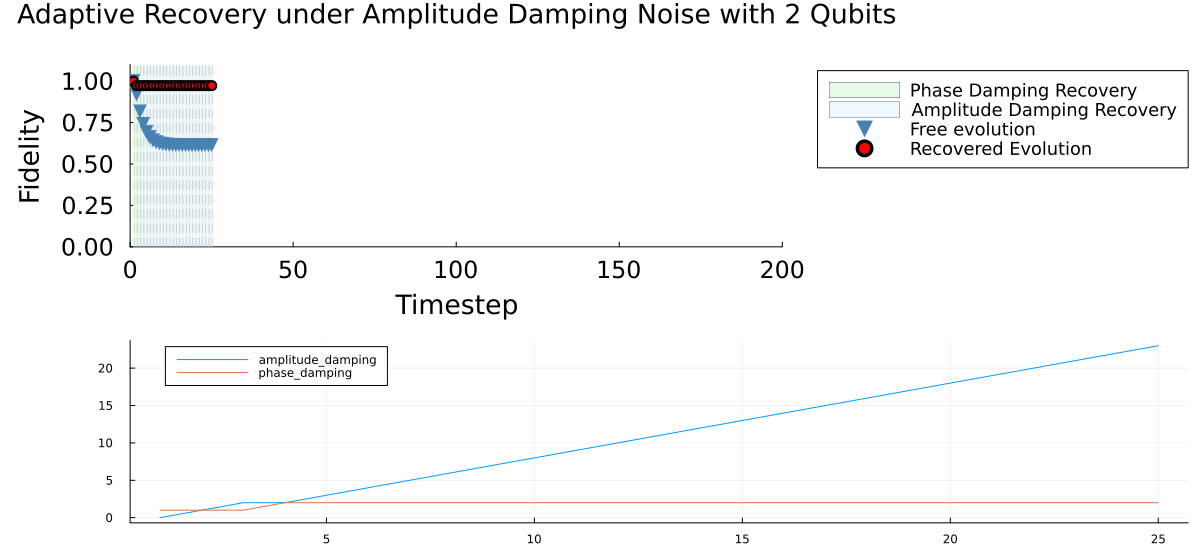

In [473]:
g1 = plot_autorecovery(
  initial_state, cfg, lgs; 
  xlims=[0, cfg.n_timesteps],
  ylims=[0.0, 1.1],
  show=false
  )
g2 = plot(
  [cumsum(initial_state.choice.c1), cumsum(initial_state.choice.c2)], 
  label=[initial_state.noise_options[1].name initial_state.noise_options[2].name]
  )

plot(g1, g2, layout=grid(2, 1), size=(1200, 550))

In [438]:
println(keys(lgs.maps[2]))

function print_all_maps(lgs, step)
  maps = lgs.maps[step]
  Nx = maps.Nx
  Xi = maps.Xi
  Cx = maps.Cx
  P = maps.P
  display(latexify(Nx; fmt="%.3f"))
  display(latexify(Xi * Nx; fmt="%.3f"))
  display(latexify(Cx * Xi * Nx; fmt="%.3f"))
  display(latexify(P * Cx * Xi * Nx; fmt="%.3f"))
end

# print_all_maps(lgs, 1)
# display("==============================")
# print_all_maps(lgs, 2)


(:Nx, :N1, :N2, :Xi, :Xi1, :Xi2, :Cx, :C1, :C2, :P)


print_all_maps (generic function with 1 method)

## Codespace Recovery

In [455]:
function reset_initial_state!(state::RecoveryState, cfg::RecoveryConfig)
    if cfg.recovery_type == "random"
        ψ0 = random_state(cfg.n_qubits)
        ρ0 = ψ0 * ψ0'
        state.ρ0 .= ρ0
        state.ρ_free .= ρ0
        state.ρ_rec .= ρ0
    elseif cfg.recovery_type == "codespace"
        sigma = cfg.sigma
        p = rand(cfg.rng)
        max_x = p * (1-p)  # Maximum allowed magnitude for |x|^2
        radius = sqrt(rand(cfg.rng) * max_x)
        x = radius * exp(2π * im * rand(cfg.rng))
        ρ = codespace_dm(cfg.n_qubits, p, x)
        ρ0 = ρ + sigma
        ρ0 = ρ0 / tr(ρ0)  # Normalize to ensure it's a valid density matrix
        state.ρ0 .= ρ0
        state.ρ_free .= ρ0
        state.ρ_rec .= ρ0
    elseif cfg.recovery_type == "inputstate"
        a, b = rand(cfg.rng, 2)
        ψ0 = input_state(cfg.n_qubits, a, b)
        ρ0 = ψ0 * ψ0'
        state.ρ0 .= ρ0
        state.ρ_free .= ρ0
        state.ρ_rec .= ρ0
    elseif cfg.recovery_type == "auto"
        # Do nothing, keep the initial state as is
        nothing
    end
end

function _run_single_state!(cfg::RecoveryConfig, state::RecoveryState, logs::RecoveryLogs, s::Int)
    initial_state = deepcopy(state)
    reset_initial_state!(initial_state, cfg)

    @debug "Initial state for system $s" initial_state.ρ0
    
    p_time = Progress(cfg.n_timesteps, desc=" State $s ", offset=1)
    for step in 1:cfg.n_timesteps
        iterate_recovery!(step, initial_state, cfg, logs)
        next!(p_time; showvalues=[
            ("Fidelity", logs.fidelities[end]),
            ("Reference", logs.ref_fidelities[end])
        ])
    end
    finish!(p_time)

    start_idx = (s - 1) * cfg.n_timesteps + 1
    end_idx = s * cfg.n_timesteps
    return start_idx, end_idx
end


_run_single_state! (generic function with 1 method)

In [456]:
cfg, state, logs = load_configuration("../configs/config.toml")

ref_fidelities = zeros(Float64, cfg.n_timesteps)
fidelities = zeros(Float64, cfg.n_timesteps)
choices = zeros(Int, cfg.n_states)

errors = 0

with_logger(debuglogger) do
p_states = Progress(cfg.n_states, desc="Adaptive Recovery ")
for s in 1:cfg.n_states
  try
    start_idx, end_idx = _run_single_state!(cfg, state, logs, s)
    ref_fidelities .+= logs.ref_fidelities[start_idx:end_idx]
    fidelities .+= logs.fidelities[start_idx:end_idx]
    choices[s] = logs.choice_history[end_idx]
    next!(p_states)
  catch e
    @error "Error in state $s: $e"
    errors += 1
  end
end
end

flush(stderr)
println("Completed with $errors errors out of $(cfg.n_states) states.")

avg_fidelities = (ref_fidelities ./ cfg.n_states, fidelities ./ cfg.n_states)

Using specified real noise from config: amplitude_damping



┌ Debug: Initial state for system 1
│   initial_state.ρ0 =
│    4×4 Matrix{ComplexF64}:
│     0.124251+0.0im       0.0-0.0im  0.0-0.0im  0.237808-0.228604im
│          0.0+0.0im       0.0+0.0im  0.0+0.0im       0.0+0.0im
│          0.0+0.0im       0.0+0.0im  0.0+0.0im       0.0+0.0im
│     0.237808+0.228604im  0.0+0.0im  0.0+0.0im  0.875749+0.0im
└ @ Main In[455]:37
┌ Debug: Discrimination probabilities
│   w =
│    2-element Vector{Float64}:
│     0.6975420473980362
│     0.30245795260196384
└ @ Main g:\UNIPA\COLLAB\SAGNIK\killing_decoherence\julia\src\adaptive_recovery.jl:148
┌ Debug: Current choice
│   state.choice.current = 2
└ @ Main g:\UNIPA\COLLAB\SAGNIK\killing_decoherence\julia\src\adaptive_recovery.jl:193
┌ Debug: Discrimination probabilities
│   w =
│    2-element Vector{Float64}:
│     0.6992108638534992
│     0.30078913614650093
└ @ Main g:\UNIPA\COLLAB\SAGNIK\killing_decoherence\julia\src\adaptive_recovery.jl:148
┌ Debug: Current choice
│   state.choice.current = 1
└ @ Ma

Completed with 0 errors out of 1 states.


([0.9267575066182202, 0.8599925672132503, 0.7991127752066753, 0.7435809277741344, 0.6929098296329476, 0.6466575885289768, 0.6044233557672204, 0.5658434695638721, 0.5305879630092346, 0.4983574020611306, 0.46888002227348, 0.4419091359374479, 0.41722078400265505, 0.39461160958028646, 0.37389693203286445, 0.3549090026489744, 0.3374954247052474, 0.32151772235047665, 0.30685004422413287, 0.293377989058522], [0.44039853856190997, 0.4403985388127819, 0.44039853881278246, 0.4403985388127822, 0.44039853881278235, 0.4403985388127822, 0.4403985388127819, 0.44039853881278235, 0.44039853881278235, 0.4403985388127819, 0.44039853881278207, 0.44039853881278207, 0.44039853881278235, 0.4403985388127828, 0.44039853881278246, 0.44039853881278246, 0.44039853881278246, 0.44039853881278174, 0.44039853881278246, 0.4403985388127822])

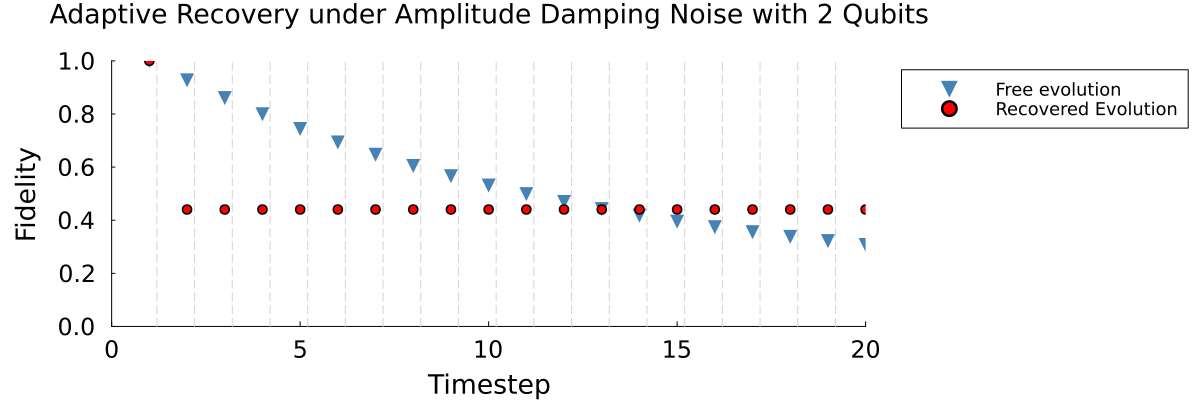

In [457]:
plot_average_fidelity(avg_fidelities[2], avg_fidelities[1], state, cfg; ylims=(0, 1), show=true, save=false)

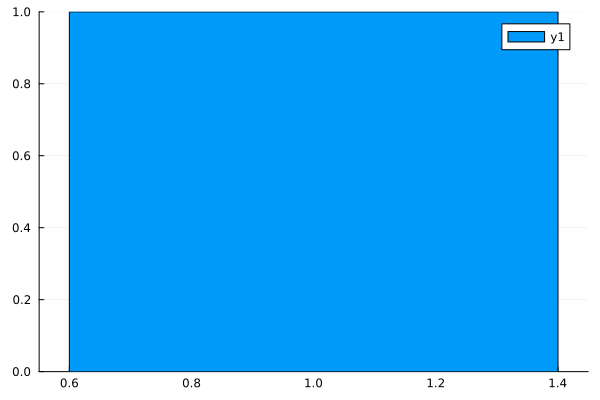

In [450]:
bar(choices)